In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('/content/spotify_data clean.csv')

In [4]:
print(df.head())

print(df.info())

print(df.shape)

                 track_id                                       track_name  \
0  3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)   
1  1oQW6G2ZiwMuHqlPpP27DB                                             OMG!   
2  7mdkjzoIYlf1rx9EtBpGmU                                      Hard 2 Find   
3  67rW0Zl7oB3qEpD5YWWE5w  Still Get Like That (ft. Project Pat & Starrah)   
4  15xptTfRBrjsppW0INUZjf                            ride me like a harley   

   track_number  track_popularity  explicit artist_name  artist_popularity  \
0             4                 0      True       Diplo                 77   
1             1                 0      True    Yelawolf                 64   
2             1                 4      True   Riff Raff                 48   
3             8                30      True       Diplo                 77   
4             2                 0      True     Rumelis                 48   

   artist_followers                      artist_genres  \
0   

In [6]:
df = df.dropna(subset=['artist_genres'])

In [7]:
top_genres = df['artist_genres'].value_counts().head(5).index

df = df[df['artist_genres'].isin(top_genres)]

In [9]:
import sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['artist_genres'] = le.fit_transform(df['artist_genres'])

In [10]:
df['explicit'] = df['explicit'].astype(int)

In [11]:
X = df[
    [
        'track_popularity',
        'artist_popularity',
        'artist_followers',
        'track_duration_min',
        'album_total_tracks',
        'explicit'
    ]
]

y = df['artist_genres']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = KNeighborsClassifier(
    n_neighbors=5
)

In [15]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [16]:
predictions

array([3, 1, 1, 2, 4, 3, 1, 0, 1, 4, 2, 2, 3, 1, 0, 4, 1, 0, 4, 3, 3, 2,
       4, 0, 0, 4, 0, 1, 0, 3, 0, 3, 0, 2, 0, 4, 0, 4, 1, 2, 3, 3, 4, 0,
       4, 1, 3, 4, 3, 2, 3, 2, 1, 1, 1, 3, 1, 1, 2, 4, 0, 1, 1, 3, 3, 4,
       3, 4, 1, 0, 3, 0, 4, 1, 0, 4, 1, 1, 0, 0, 2, 1, 4, 0, 0, 3, 4, 2,
       3, 2, 1, 2, 2, 1, 3, 1, 4, 4, 2, 0, 4, 1, 1, 0, 1, 1, 4, 1, 4, 3,
       3, 1, 3, 4, 3, 3, 4, 3, 1, 1, 0, 0, 4, 4, 3, 1, 0, 4, 1, 2, 1, 1,
       4, 2, 2, 4, 4, 1, 4, 4, 2, 2, 2, 4, 0, 1, 1, 1, 4, 2, 1, 0, 0, 0,
       2, 3, 1, 3, 1, 4, 0, 3, 4, 1, 0, 3, 0, 1, 0, 1, 2, 1, 0, 4, 0, 1,
       0, 4, 2, 4, 0, 0, 4, 1, 1, 3, 3, 2, 1, 3, 4, 4, 2, 4, 1, 0, 0, 0,
       2, 2, 1, 4, 3, 1, 0, 3, 0, 4, 4, 3, 2, 1, 0, 1, 3, 4, 0, 4, 3, 4,
       3, 0, 0, 3, 0, 4, 0, 3, 2, 0, 0, 4, 1, 4, 1, 1, 2, 1, 1, 1, 2, 1,
       3, 3, 3, 0, 0, 2, 3, 4, 3, 2, 0, 2, 2, 3, 2, 0, 0, 2, 4, 1, 0, 4,
       4, 4, 1, 1, 0, 0, 4, 3, 4, 0, 0, 2, 4])

In [17]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9963898916967509


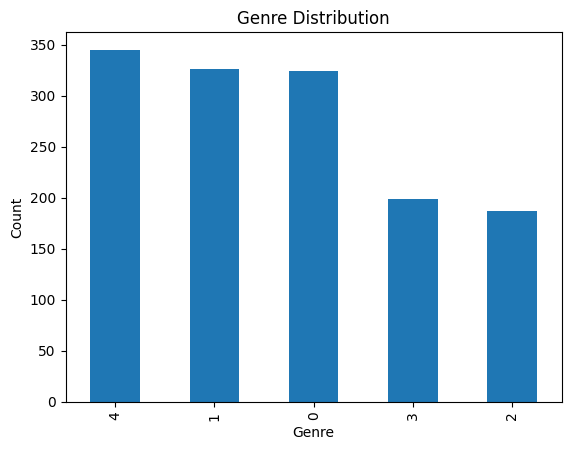

In [18]:
import matplotlib.pyplot as plt

df['artist_genres'].value_counts().plot(kind='bar')

plt.title("Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

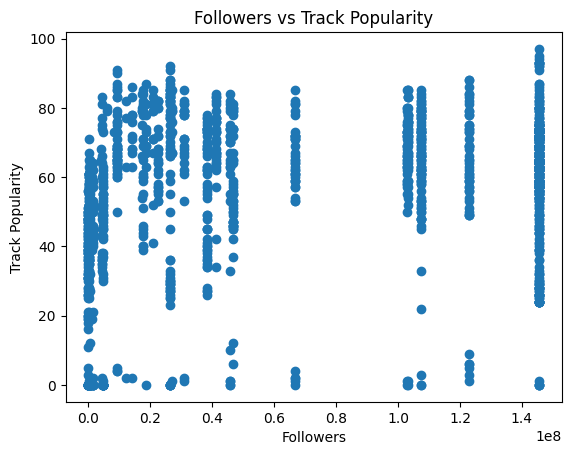

In [19]:
plt.scatter(
    df['artist_followers'],
    df['track_popularity']
)

plt.xlabel("Followers")
plt.ylabel("Track Popularity")
plt.title("Followers vs Track Popularity")

plt.show()

What are we predicting?

We are predicting the artist's music genre based on song and artist features such as track popularity, artist popularity, number of followers, track duration, album size, and whether the track is explicit.

Why KNN?

Because KNN classifies a new song by finding the most similar songs in the training dataset. The majority genre among the nearest neighbors becomes the predicted genre.